In [11]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt


In [12]:
"""
Exercise 4: NumPy Array Operations
Complete the following tasks using NumPy.
"""


# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0 
# (5 points)
# TODO: Create the matrix described above -- DONE
ones_matrix = np.ones((5,5), dtype=int)
ones_matrix[1:-1, 1:-1] = 0
print("------Task One------")
print(ones_matrix)
print()


# Task 2: Normalize a random array
# (5 points)
# TODO: Normalize each column to have mean=0 and std=1 -- DONE
np.random.seed(42)
random_data = np.random.randn(100, 3)
mean = random_data.mean(axis=0)
std = random_data.std(axis=0)
standardised = (random_data - mean) / std
print("------Task Two------")
print("Standardized:", standardised)
print("New Mean:", np.round(standardised.mean(axis=0), 2))
print("New Std Dev:", np.round(standardised.std(axis=0), 2))
print()

# Task 3: Implement linear regression solution using normal equation
# (10 points)
# Given X (features) and y (target), compute theta
# theta = (X^T X)^(-1) X^T y
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# TODO: Calculate theta_hat using the normal equation - DONE
theta_hat = np.linalg.solve(X. T @ X, X. T @ y)
# TODO: Print the estimated coefficients and compare with true_theta - DONE
print("------Task Three------")
print("Estimated theta:", theta_hat)
print("True theta:", true_theta)
print("Difference:", np.abs(theta_hat - true_theta))
print()

------Task One------
[[1 1 1 1 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 0 0 0 1]
 [1 1 1 1 1]]

------Task Two------
Standardized: [[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051

In [13]:
"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration (10 points)
# TODO: Display basic information about the dataset - DONE
print("------Task One------")
print(df.info())
print(df.describe())
print()

# TODO: Identify and count missing values - DONE
missing_values_count = df.isna().sum()
print("Missing values:\n", missing_values_count)
print()


# TODO: Fill missing exam_score with the mean score for the student's major - DONE
major_mean = df.groupby('major')['exam_score'].transform('mean')
df['exam_score'] = df['exam_score'].fillna(major_mean)

# TODO: Fill missing hours_studied with the median for the student's year - DONE 
year_median = df.groupby('year')['hours_studied'].transform('median')
df['hours_studied'] = df['hours_studied'].fillna(year_median)

print("Missing values after fill:")
print(df.isna().sum())
print()

# Task 2: Analysis (10 points)
# TODO: Calculate and display the average exam_score by major - DONE
avg_by_major = df.groupby('major')['exam_score'].mean()
print("------Task Two------")
print("Average exam score by major:")
print(avg_by_major)
print()

# TODO: Find the major with the highest average exam_score - DONE
highest_avg_major = avg_by_major.idxmax()
highest_avg_major_score = avg_by_major.max()
print("Highest average exam score")
print(f"Major: {highest_avg_major}\nScore: {highest_avg_major_score}")
print()


# TODO: Calculate the correlation between hours_studied and exam_score - DONE
corr = df['hours_studied'].corr(df['exam_score'])
print("Correlation between hours_studied and exam_score:", corr)

# TODO: Create a new column 'performance' with categories:
#       'Excellent' (>90), 'Good' (80-90), 'Average' (70-80), 'Needs Improvement' (<70) - DONE
def performance_label(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'
    
df['performance'] = df['exam_score'].apply(performance_label)
print(df[['exam_score', 'performance']].head())
print()

# Task 3: Advanced Analysis (10 points)
# TODO: For each major and year combination, calculate: - DONE
#       - Number of students
#       - Average exam score
#       - Average hours studied
group_stats = df.groupby(['major', 'year']).agg(
    num_student=('student_id', 'size'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
)
print("------Task Three------")
print(group_stats)

# TODO: Identify top 5 students based on exam_score (handle ties appropriately) - DONE
exam_threshold = df['exam_score'].nlargest(5).min()
top_students = df[df['exam_score'] >= exam_threshold].sort_values('exam_score', ascending=False)
print(top_students[['student_id', 'major', 'year', 'exam_score']])

# TODO: Create a pivot table showing average exam_score by major (rows) and year (columns) - DONE
pivot_table = df.pivot_table(
    index='major',
    columns='year',
    values='exam_score',
    aggfunc='mean'
)
print(pivot_table)

------Task One------
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), str(1)
memory usage: 9.5 KB
None
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.750000    2.000000   68.206910               2.000

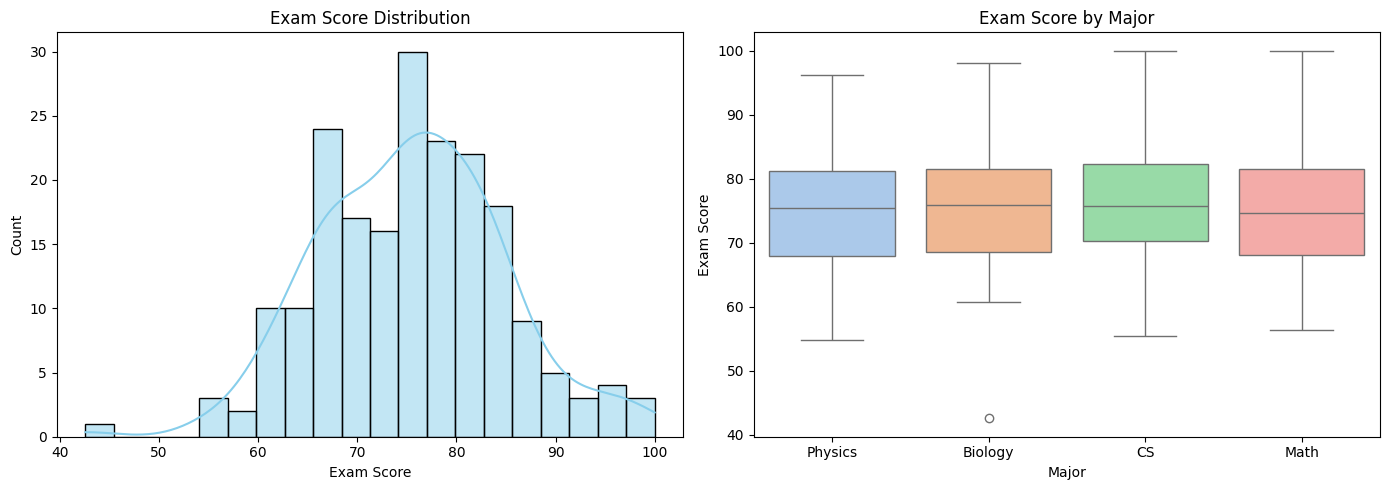

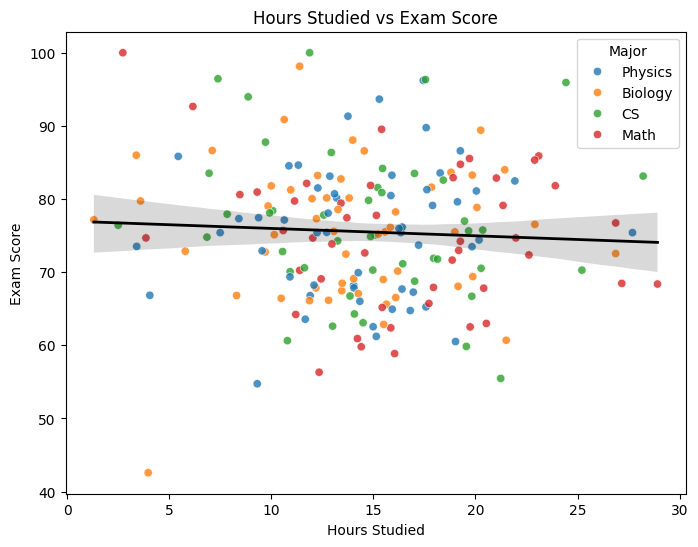

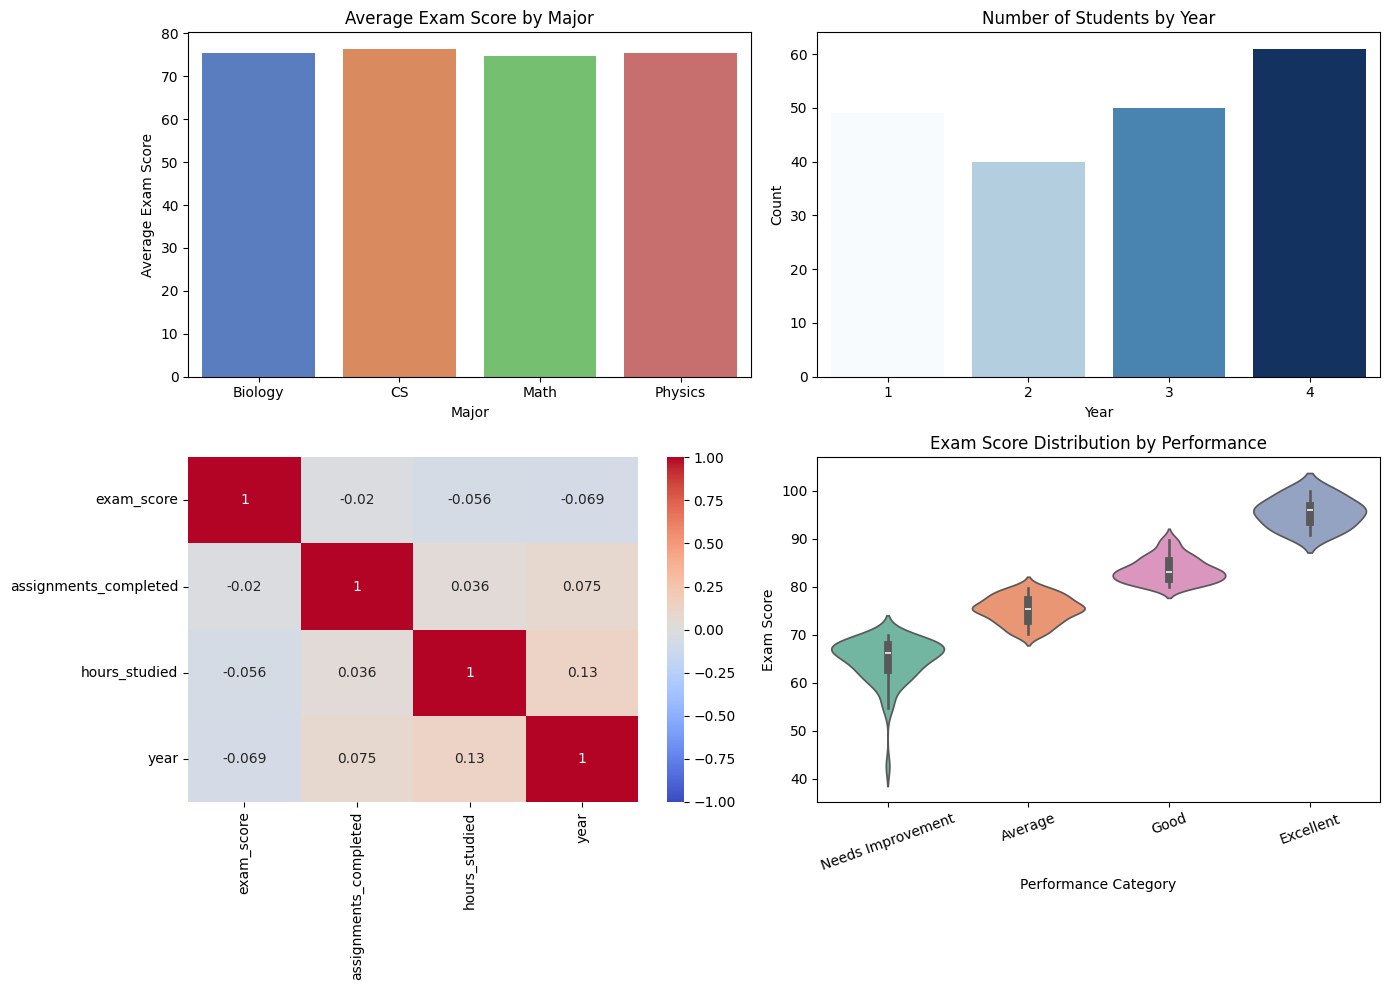

In [14]:
"""
Exercise 6: Data Visualization
Create meaningful visualizations using the dataset from Exercise 5.
"""


# Continue using the df from Exercise 5

# Task 1: Distribution Visualization (8 points)
plt.figure(figsize=[14,5])

# TODO: Create a figure with 2 subplots side by side
#       Left: Histogram of exam scores with KDE overlay - DONE
plt.subplot(1, 2, 1)
sns.histplot(df['exam_score'].dropna(), kde=True, bins=20, color='skyblue')
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')
plt.ylabel('Count')

# Right: Box plot of exam scores by major - DONE
plt.subplot(1, 2, 2)
sns.boxplot(
    x='major',
    y='exam_score',
    data=df,
    hue='major',
    palette='pastel',
    legend=False
)
plt.title('Exam Score by Major')
plt.xlabel('Major')
plt.ylabel('Exam Score')
# TODO: Add appropriate titles, labels, and styling - DONE

plt.tight_layout()
plt.show()


# Task 2: Relationship Visualization (8 points)
# TODO: Create a scatter plot of hours_studied vs exam_score - DONE
# TODO: Color points by major - DONE
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    hue='major',
    palette='tab10',
    alpha=0.8
)
# TODO: Add a regression line - DONE
sns.regplot(
    data=df,
    x='hours_studied',
    y='exam_score',
    scatter=False,
    color='black',
    line_kws={'linewidth' : 2}
)
# TODO: Include appropriate legends, titles, and axis labels - DONE
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend(title='Major')
plt.show()


# Task 3: Advanced Dashboard (9 points)
fig, axes = plt.subplots(2,2, figsize=(14,10))

# TODO: Create a 2x2 subplot figure containing:
# 1. Bar chart: Average exam score by major - DONE
sns.barplot(
    ax=axes[0, 0],
    x=avg_by_major.index,
    y=avg_by_major.values,
    hue=avg_by_major.index,
    palette='muted',
    legend=False
)
axes[0,0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')

# 2. Count plot: Number of students by year - DONE
sns.countplot(
    ax=axes[0, 1],
    x='year',
    data=df,
    hue='year',
    palette='Blues',
    legend=False
)
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. Heat map: Correlation matrix of numerical columns - DONE
correlation_matrix = df[['exam_score', 'assignments_completed', 'hours_studied', 'year']].corr()
sns.heatmap(
    correlation_matrix,
    ax=axes[1, 0],
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)

# 4. Violin plot: Exam score distribution by performance category - DONE
sns.violinplot(
    ax=axes[1, 1],
    x='performance',
    y='exam_score',
    data=df,
    hue='performance',
    palette='Set2',
    order=['Needs Improvement', 'Average', 'Good', 'Excellent'],
    legend=False
)
axes[1, 1].set_title('Exam Score Distribution by Performance')
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
for label in axes[1, 1].get_xticklabels():
    label.set_rotation(20)

plt.tight_layout()
plt.show()
# TODO: Adjust layout, add titles, and ensure readability - DONE




  age_group  num_customers    ave_income     avg_clv      total_clv
0     18-25             81  50634.018330  718.371170   58188.064760
1     26-35             73  48747.148046  747.738562   54584.915035
2     36-50            160  48516.895668  732.796612  117247.457917
3     51-70            186  50713.163384  762.693498  141860.990683
CLV 90th percentile: 1222.94
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
426   42  68713.567863                   8          154.285448    0.333333   
213   41  45580.608009                   7          164.920221    0.416667   
410   44  49344.934596                   6          177.097211    0.500000   
194   44  57331.964922                   6          176.640590    0.500000   
244   28  29255.076913                   7          159.784979    0.416667   

             clv age_group  
426  1645.711441     36-50  
213  1635.458860     36-50  
410  1593.874900     36-50  
194  1589.765308     36-50  
244  1584.534373 

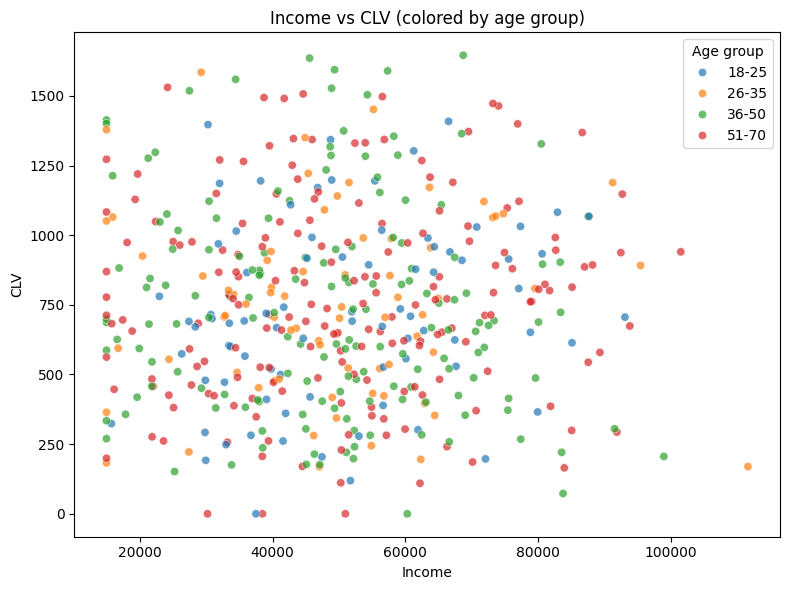

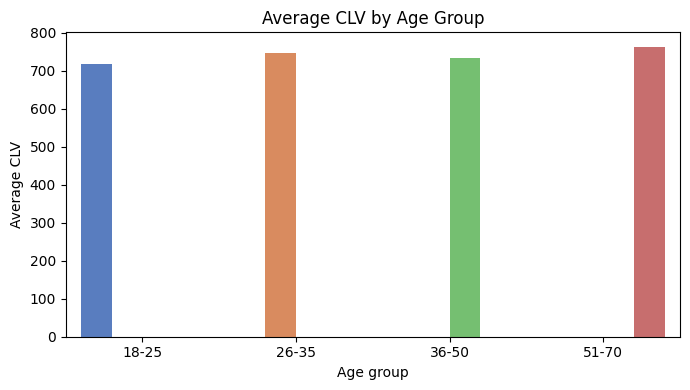

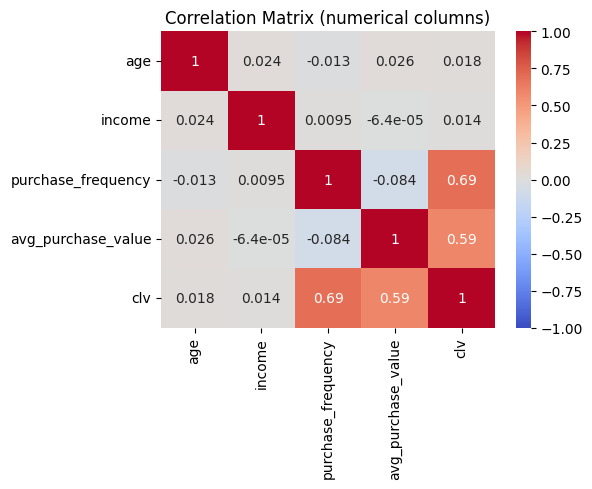

In [15]:
"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

# Scenario: You're analyzing customer data for an e-commerce company.
# Generate synthetic data and provide insights.

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# TODO: Calculate customer lifetime value (CLV) - DONE
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)

max_freq = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_freq)
customers['clv'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])


# TODO: Create age groups: 18-25, 26-35, 36-50, 51-70 - DONE
# TODO: For each age group, calculate: - DONE
#       - Number of customers
#       - Average income
#       - Average CLV
#       - Total CLV

age_bin_edges = [18, 25, 35, 50, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=age_bin_edges, labels=labels, right=True, include_lowest=True)

age_stats = customers.groupby('age_group').agg(
    num_customers=('age', 'size'),
    ave_income=('income', 'mean'),
    avg_clv=('clv', 'mean'),
    total_clv=('clv', 'sum')
).reset_index()
print(age_stats)


# TODO: Identify top 10% of customers by CLV - DONE
clv_threshold = customers['clv'].quantile(0.90)
top_10pct = customers[customers['clv'] >= clv_threshold].sort_values('clv', ascending=False)
print(f"CLV 90th percentile: {clv_threshold:.2f}")
print(top_10pct.head())


# TODO: Create visualizations: - DONE
#       1. Scatter plot of income vs CLV (color by age group)
#       2. Bar chart of average CLV by age group
#       3. Correlation heatmap
plt.figure(figsize=(8,6))
sns.scatterplot(data=customers, x='income', y='clv', hue='age_group', alpha=0.7)
plt.title('Income vs CLV (colored by age group)')
plt.xlabel('Income')
plt.ylabel('CLV')
plt.legend(title='Age group')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
sns.barplot(
    data=age_stats,
    x='age_group',
    y='avg_clv',
    hue='age_group',
    palette='muted',
    legend=False
)
plt.title('Average CLV by Age Group')
plt.xlabel('Age group')
plt.ylabel('Average CLV')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,5))
num_cols = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'clv']
sns.heatmap(customers[num_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix (numerical columns)')
plt.tight_layout()
plt.show()


# TODO: Write a brief analysis paragraph (as a markdown cell) - DONE
#       summarizing key findings and recommendations

## Brief Analysis Paragraph
The analysis shows that the customer lifetime value is mainly influenced by how often customers purchase and how much they spend per purchase. The 51-70 age group has the highest average and total CLV, making it a potential target for retention efforts. However, the correlation results show that age and income are not strong predictors of CLV. Instead, the company should focus on trying to increase purchase frequency and average purchase value through loyalty bonuses, targeted retention promotions for customers who already exhibit such a strong buying behaviour, etc. 